<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/DA/EDA-BenhTieuDuong/EDA-Benh_Dai-Thao-Duong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Phân tích khám phá về bệnh đái tháo đường**

##**1.Định nghĩa vấn đề**
+ **Mô tả**:
   + Bộ dữ liệu gồm 768 mẫu từ bệnh nhân đều là nữ giới, ít nhất 21 tuổi, và có nguồn gốc người da đỏ Pima, sống gần Phoenix, Arizona.
   + 8 đặc điểm được đo từ mỗi mẫu + 1 biến phân loại (có/không mắc tiểu đường)
+ **Dữ liệu vào**:
   + Số lần mang thai (lần)
   + Nồng độ glucose huyết tương sau 2 giờ trong xét nghiệm dung nạp glucose đường uống (mg/dL)
   + Huyết áp tâm trương (mm Hg)
   + Độ dày nếp gấp da cơ tam đầu (mm)
   + Nồng độ insulin huyết thanh sau 2 giờ (mu U/ml)
   + Chỉ số khối cơ thể BMI (kg/m²)
   + Hàm phả hệ tiểu đường ()
   + Tuổi (năm)
   + Biến phân loại (nhị phân)
+ **Dữ liệu ra**:
   + Dự đoán bệnh nhân có tiểu đường không (Biến phân loại 0 hoặc 1)
+ **Mục tiêu**:
   + Phân tích bộ dữ liệu bệnh đái tháo đường nhằm hiểu rõ các yếu tố liên quan đến nguy cơ mắc bệnh.
   + Vận dụng kiến thức về dinh dưỡng để đánh giá ảnh hưởng của chế độ ăn uống đến tình trạng bệnh.


## **2.Chuẩn bị vấn đề**

### **2.1.Khai báo thư viện**

In [36]:
# Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.model_selection as mod
import sklearn.neighbors as nei
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import LeaveOneOut
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report, precision_recall_curve, average_precision_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import operator
%matplotlib inline

### **2.2.Nạp dữ liệu**

In [37]:
#load data
pima = pd.read_csv('https://raw.githubusercontent.com/mihhwiNick/DA_project/refs/heads/main/EDA-BenhTieuDuong/pima-indians-diabetes.data.csv')

## **3.Mô tả thống kê**

#### **3.1. Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [38]:
# Get shape
print(f'+ Shape: {pima.shape}')

# Get types
print(f'\n+ Data Types:\n{pima.dtypes}')

# Check the first 5 rows (head)
print('\n+ First 5 rows:')
display(pima.head(5))

# Check the last 5 rows (tail)
print('\n+ Last 5 rows:')
display(pima.tail(5))

# info
print('\n + Basic Information: ')
pima.info()

+ Shape: (768, 9)

+ Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

+ First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



+ Last 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0



 + Basic Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


**Nhận xét**:
+ Dữ liệu có 8 tính chất để phân lớp: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
+ Các giá trị đều là số học, thuộc kiểu int64 và float64
+ Tổng số dòng dữ liệu là 768 dòng
+ Dữ liệu phân lớp nằm ở cột Outcome, gồm 2 giá trị: 0 (không mắc bệnh) và 1 (mắc bệnh)


#### **3.2. Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [39]:
description = pima.drop(columns=["Outcome"]).describe().T
display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


**Nhận xét**:
+ **Pregnancies:** Trung bình 3.84, dao động 0–17 → hợp lý, vì có thể có phụ nữ chưa mang thai.
+ **Glucose:** Giá trị trung bình là 120.89, với mức cao nhất là 199. Phân phối cho thấy có sự đa dạng về mức đường huyết trong nhóm nghiên cứu, phản ánh rõ nguy cơ tiểu đường.
+ **BloodPressure:** Huyết áp trung bình là 69.1, nằm trong ngưỡng bình thường. Giá trị cao nhất là 122, cho thấy có một số trường hợp tăng huyết áp.
+ **SkinThickness:** Độ dày lớp mỡ dưới da trung bình là 20.5, với giá trị cao nhất là 99. Phân phối khá rộng, thể hiện sự khác biệt về thể trạng giữa các cá nhân.
+ **Insulin:** Mức insulin trung bình là 79.8, nhưng giá trị cao nhất lên tới 846, cho thấy có một số trường hợp rối loạn chuyển hóa rõ rệt.
+ **BMI:** Chỉ số khối cơ thể trung bình là 31.99, nằm trong ngưỡng thừa cân. Một số cá nhân có BMI rất cao (tối đa 67.1), cho thấy nguy cơ béo phì.
+ **DiabetesPedigreeFunction:** Hệ số di truyền trung bình là 0.47, dao động từ 0.078 đến 2.42. Phân phối này phản ánh mức độ ảnh hưởng của yếu tố di truyền đến nguy cơ mắc bệnh.
+ **Age:** Tuổi trung bình là 33.24, dao động từ 21 đến 81. Phân phối tuổi phù hợp với nhóm dân số trưởng thành, có nguy cơ tiểu đường tăng theo tuổi.


#### **3.3. Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [40]:
# Loại bỏ cột Outcome khi kiểm tra giá trị 0
cols_to_check = pima.columns.drop("Outcome")
rows_with_zero = (pima[cols_to_check] == 0).any(axis=1)
count_rows_with_zero = rows_with_zero.sum()

has_null = pima.isnull().sum().any()
has_nan  = pima.isna().sum().any()
n_duplicated = pima.duplicated().sum()

print('Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display(pima[pima.isnull().any(axis=1)])

print(f'+ Có giá trị NaN: {has_nan}')
if has_nan:
    display(pima[pima.isna().any(axis=1)])

print(f'+ Số dòng trùng: {n_duplicated}')
if n_duplicated > 0:
    s_query1 = "`Pregnancies`==6 and `Glucose`==148 and `Outcome`==1"
    s_query2 = "`Pregnancies`==1 and `Glucose`==85 and `Outcome`==0"
    display(pima.query(s_query1))
    display(pima.query(s_query2))
    display(pima[pima.duplicated()])

zero_counts_all = (pima == 0).sum()


cols_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Đếm số dòng có giá trị = 0 ở các cột này
zero_counts = (pima[cols_check] == 0).sum()

print("Số lượng dòng có giá trị = 0 ở từng cột được chọn:")
print(zero_counts)

Tính toàn vẹn dữ liệu:
+ Có giá trị Null: False
+ Có giá trị NaN: False
+ Số dòng trùng: 0
Số lượng dòng có giá trị = 0 ở từng cột được chọn:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


**Nhận xét**:
+ Không có dữ liệu nào trùng nhau
+ Dữ liệu không có giá trị rỗng (NaN, Null).
+ Tuy nhiên, khi kiểm tra chi tiết, phát hiện một số cột có giá trị = 0 không hợp lý về mặt y học, được coi là dữ liệu thiếu:
  + Glucose: không thể bằng 0 vì cơ thể luôn có đường huyết lưu hành.

  + BloodPressure: không thể bằng 0, vì huyết áp 0 chỉ xảy ra khi đã tử vong.

  + SkinThickness: không thể bằng 0, lớp mỡ dưới da luôn có độ dày nhất định.

  + Insulin: không thể bằng 0, vì tuyến tụy luôn tiết insulin nền.

  + BMI: không thể bằng 0, vì chỉ số khối cơ thể = 0 nghĩa là cân nặng = 0, điều này không thực tế.

## **4.Phân tích khám phá dữ liệu**

### **4.1.Phân tích đơn biến (Univariable Analysis)**

####**4.1.1. Đối với các biến số định lượng (Numerical Variables)**

**Các chỉ số sức khỏe định lượng như Glucose, BMI... có phân bố ra sao? Chúng có bình thường không? Có bị ảnh hưởng bởi những giá trị bất thường nào cần phải xử lý không?**

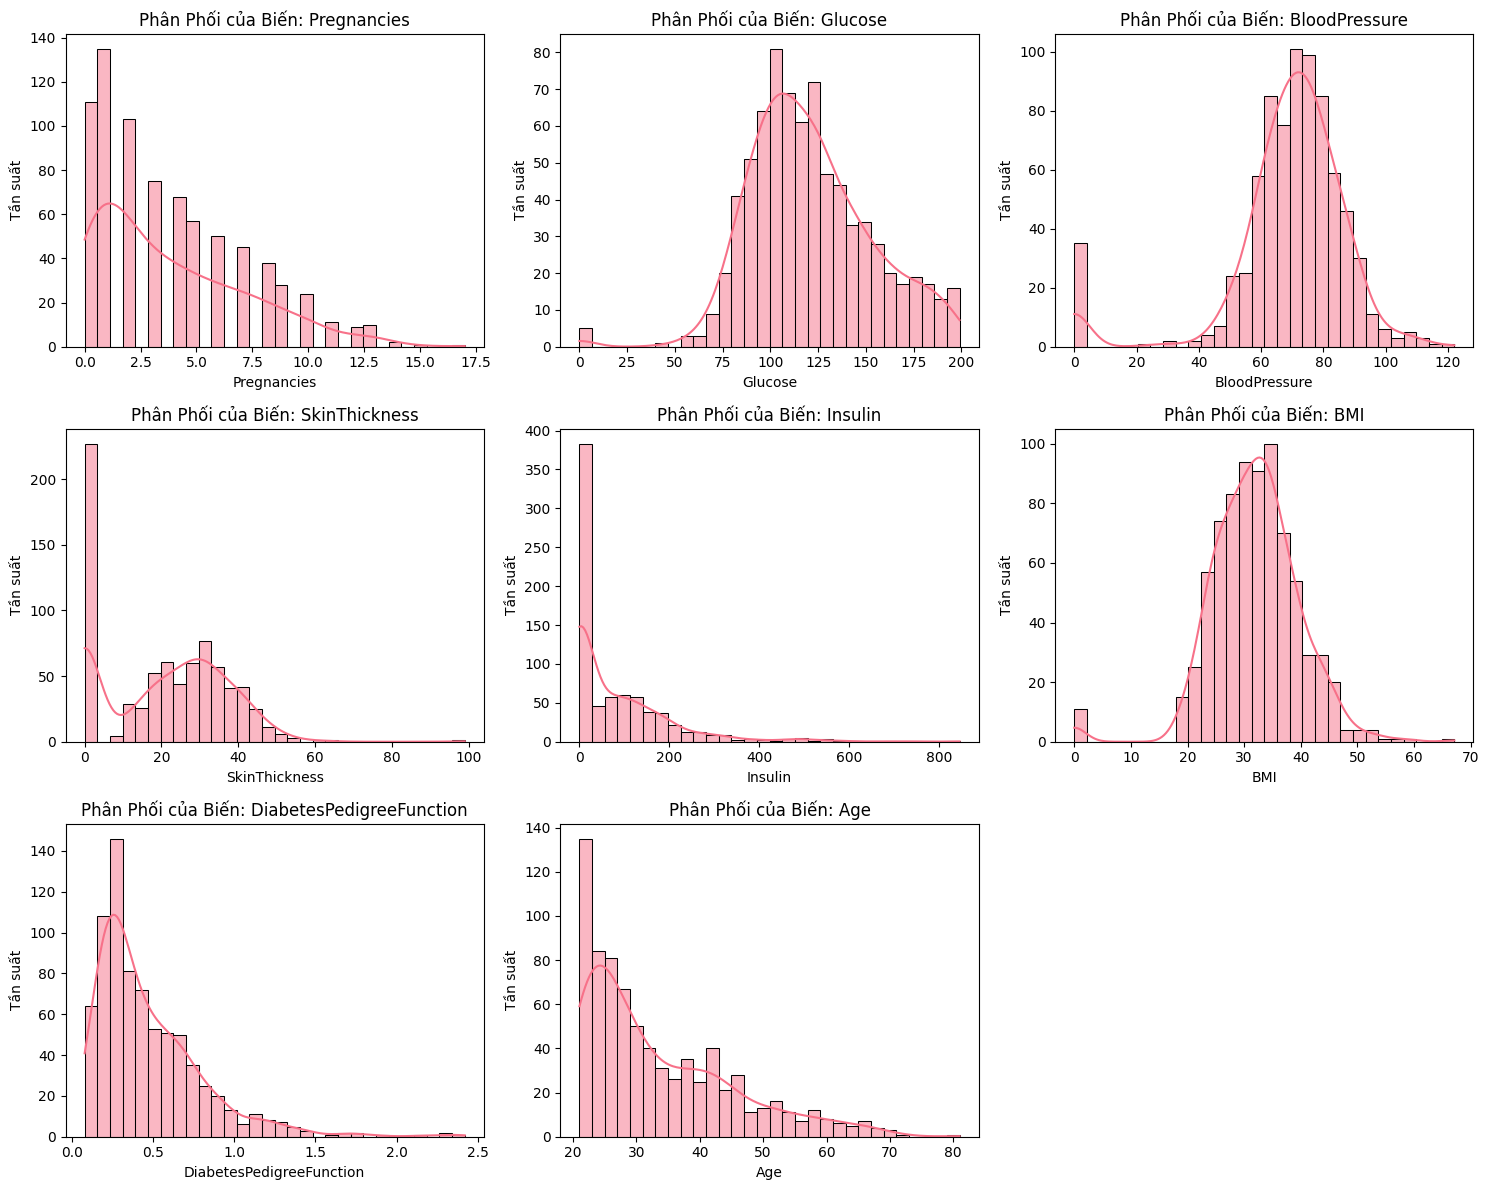

In [41]:
import matplotlib.pyplot as plt


# Giả sử bạn có DataFrame df và danh sách các cột số numerical_cols
# Để code có thể chạy, giả sử chúng ta có dữ liệu mẫu:
# import numpy as np
# df = pd.DataFrame(np.random.rand(100, 7), columns=[f'col_{i}' for i in range(7)])
# numerical_cols = df.columns.tolist()

# Số cột trên mỗi hàng
n_cols = 3
# Tính toán số hàng cần thiết
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Tạo một figure và một lưới các subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))

# Vòng lặp qua từng cột số và vẽ biểu đồ trên từng subplot
for i, col in enumerate(numerical_cols):
    row_idx = i // n_cols
    col_idx = i % n_cols

    # Đảm bảo trục ax là một mảng 2D
    ax = axes[row_idx, col_idx] if n_rows > 1 else axes[col_idx]

    # Vẽ biểu đồ histplot với kde
    sns.histplot(pima[col], kde=True, bins=30, ax=ax)

    # Đặt tiêu đề và nhãn
    ax.set_title(f'Phân Phối của Biến: {col}', fontsize=12)
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Tần suất', fontsize=10)

# Xóa các subplot trống nếu có
for j in range(len(numerical_cols), n_rows * n_cols):
    row_idx = j // n_cols
    col_idx = j % n_cols
    if n_rows > 1:
        fig.delaxes(axes[row_idx, col_idx])
    else:
        fig.delaxes(axes[col_idx])

# Điều chỉnh layout để tránh tiêu đề và nhãn bị chồng lên nhau
plt.tight_layout()
plt.show()

**Dựa trên các biểu đồ phân phối và thống kê mô tả, đây là đánh giá về từng biến số:**

- Pregnancies: Biểu đồ cho thấy phân phối lệch phải (skewed right). Hầu hết phụ nữ có số lần mang thai ít (dưới 5 lần), với một số ít trường hợp có số lần mang thai rất cao (lên đến 17 lần).

- Glucose: Phân phối có vẻ gần với phân phối chuẩn hơn, nhưng có một số giá trị cao ở phía bên phải, cho thấy sự hiện diện của những người có nồng độ glucose cao.

- BloodPressure: Phân phối tương đối đối xứng, tập trung quanh giá trị trung bình. Tuy nhiên, có một số giá trị bằng 0, như đã nhận xét trước đó, là không hợp lý và cần xử lý.

- SkinThickness: Biểu đồ có đỉnh nhọn ở gần 0 và sau đó giảm dần, cho thấy nhiều giá trị bằng 0 (không hợp lý) và phân phối lệch phải.

- Insulin: Phân phối lệch phải rất mạnh, với nhiều giá trị bằng 0 (không hợp lý) và một số giá trị rất cao. Điều này cho thấy sự đa dạng lớn về mức insulin trong tập dữ liệu.

- BMI: Phân phối có vẻ gần với phân phối chuẩn, nhưng có một số giá trị bằng 0 (không hợp lý) và một số giá trị rất cao, cho thấy sự hiện diện của người thừa cân và béo phì.

- DiabetesPedigreeFunction: Phân phối lệch phải mạnh, tập trung ở các giá trị thấp hơn. Điều này phản ánh rằng hầu hết mọi người có mức độ ảnh hưởng di truyền đến bệnh tiểu đường ở mức thấp hoặc trung bình.

- Age: Phân phối lệch phải, với phần lớn người tham gia ở độ tuổi trẻ và trung niên, và một số ít người cao tuổi hơn.


#####**4.1.1.1.Phát hiện giá trị bất thường**

In [42]:
# Các cột mà giá trị 0 được coi là bất thường
cols_with_zero_anomaly = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print("\n\n--- Phát Hiện Giá Trị 0 Bất Thường ---")
print("Số lượng giá trị 0 trong các cột quan trọng:")

for col in cols_with_zero_anomaly:
    count = (pima[col] == 0).sum()
    print(f"- {col}: {count} giá trị 0")

# Thay thế các giá trị 0 bằng NaN (Not a Number)
pima[cols_with_zero_anomaly] = pima[cols_with_zero_anomaly].replace(0, np.nan)

print("\nCác giá trị 0 đã được thay thế bằng NaN. Kiểm tra lại thông tin DataFrame:")
pima.info()



--- Phát Hiện Giá Trị 0 Bất Thường ---
Số lượng giá trị 0 trong các cột quan trọng:
- Glucose: 5 giá trị 0
- BloodPressure: 35 giá trị 0
- SkinThickness: 227 giá trị 0
- Insulin: 374 giá trị 0
- BMI: 11 giá trị 0

Các giá trị 0 đã được thay thế bằng NaN. Kiểm tra lại thông tin DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  


**Nhận Diện Vấn Đề (Phát Hiện Giá Trị 0 Bất Thường):**

- Vấn đề: Các cột Glucose (đường huyết), BloodPressure (huyết áp), SkinThickness (độ dày da), Insulin (insulin), và BMI (chỉ số khối cơ thể) xuất hiện giá trị 0.

- Lý do "Bất Thường": Trong bối cảnh y tế, giá trị 0 ở các chỉ số sinh lý này là gần như không thể xảy ra trên thực tế. Ví dụ:

  - Glucose = 0: Một người không thể có lượng đường trong máu bằng 0 và vẫn sống.

  - BloodPressure = 0: Huyết áp bằng 0 là không thể.

  - BMI = 0: Chỉ số khối cơ thể bằng 0 là vô lý.

**Kết luận:** Các giá trị 0 này thực chất là giá trị thiếu (missing values) đã được mã hóa không đúng cách (thay vì để trống hoặc ký hiệu NA, người ta đã điền số 0). Nếu giữ nguyên, chúng sẽ làm sai lệch hoàn toàn các mô hình phân tích hoặc dự đoán.

####**4.1.2.Đối với biến số định tính (Categorical Variable)**

 **Tỷ lệ người mắc bệnh tiểu đường (Outcome = 1) so với người không mắc (Outcome = 0) là bao nhiêu?" Liệu chúng ta đang có một tập dữ liệu cân bằng hay thiên lệch?**

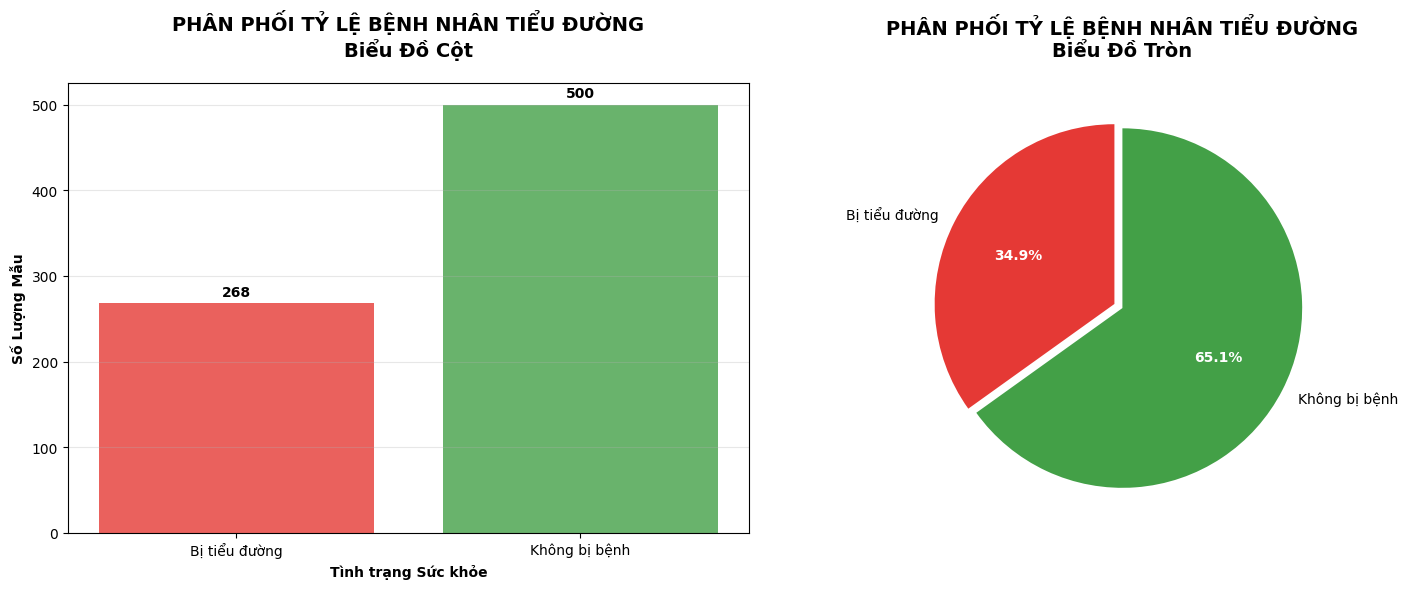

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Tạo dữ liệu mẫu giống với dữ liệu về bệnh tiểu đường (có khoảng 768 mẫu)
# Với 268 người bị tiểu đường (1) và 500 người không bị (0)
# Đây chỉ là ví dụ để code có thể chạy.
data = {'Outcome': np.concatenate([np.zeros(500), np.ones(268)])}
pima = pd.DataFrame(data)

# 1. Phân loại bệnh
def classify_outcome(outcome):
    if outcome == 1:
        return 'Bị tiểu đường'
    else:
        return 'Không bị bệnh'

pima['outcome_category'] = pima['Outcome'].apply(classify_outcome)
outcome_counts = pima['outcome_category'].value_counts()

# Đảm bảo thứ tự các nhóm khi vẽ biểu đồ
category_order = ['Bị tiểu đường', 'Không bị bệnh']
outcome_counts = outcome_counts.reindex(category_order)

# 2. Tạo hình vẽ với 2 subplot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- BIỂU ĐỒ CỘT ---
# Đổi màu sắc cho đúng với yêu cầu
colors_bar = ['#e53935', '#43a047']
bars = ax1.bar(outcome_counts.index, outcome_counts.values, color=colors_bar, alpha=0.8)

ax1.set_title('PHÂN PHỐI TỶ LỆ BỆNH NHÂN TIỂU ĐƯỜNG\nBiểu Đồ Cột', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Tình trạng Sức khỏe', fontweight='bold')
ax1.set_ylabel('Số Lượng Mẫu', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Thêm số liệu lên trên mỗi cột
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

# --- BIỂU ĐỒ TRÒN ---
# Đổi màu sắc và explode để giống với yêu cầu
colors_pie = ['#e53935', '#43a047']
explode = (0.05, 0) # Tách miếng 'Bị tiểu đường' ra một chút

wedges, texts, autotexts = ax2.pie(outcome_counts.values,
                                    labels=outcome_counts.index,
                                    autopct='%1.1f%%',
                                    colors=colors_pie,
                                    startangle=90,
                                    explode=explode)

ax2.set_title('PHÂN PHỐI TỶ LỆ BỆNH NHÂN TIỂU ĐƯỜNG\nBiểu Đồ Tròn', fontsize=14, fontweight='bold', pad=20)

# Làm đẹp cho phần trăm trong pie chart
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

plt.tight_layout()
plt.show()

In [47]:
pima

,Outcome,outcome_category
0,0.0,Không bị bệnh
1,0.0,Không bị bệnh
2,0.0,Không bị bệnh
3,0.0,Không bị bệnh
4,0.0,Không bị bệnh
...,...,...
763,1.0,Bị tiểu đường
764,1.0,Bị tiểu đường
765,1.0,Bị tiểu đường
766,1.0,Bị tiểu đường


**Đánh giá**
 - Tập dữ liệu cho thấy sự phân bố không đồng đều giữa hai nhóm bệnh. Đa số mẫu (65.1%) thuộc nhóm không bị bệnh, trong khi tỷ lệ người bị tiểu đường chiếm 34.9%. Điều này phản ánh thực tế rằng trong tập dữ liệu này, số người không mắc bệnh tiểu đường nhiều hơn đáng kể so với người mắc bệnh.

**Dựa trên tiêu chí nào để xác định yếu tố ảnh hưởng đến việc 34,9% mắc bệnh?**

In [45]:
# ====================
# THIẾT LẬP MÔI TRƯỜNG
# ====================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ
plt.style.use('default')
sns.set_palette("husl")

# ====================
# CHUẨN BỊ DỮ LIỆU
# ====================
# Giả sử chúng ta có dataframe 'pima' với các cột: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age, Outcome

# Tạo các biến phân loại từ các biến liên tục
def create_categorical_variables(df):
    # Phân nhóm tuổi
    df['Age_Group'] = pd.cut(df['Age'],
                            bins=[0, 30, 45, 60, 100],
                            labels=['<30', '30-45', '45-60', '>60'])

    # Phân loại BMI theo WHO
    df['BMI_Category'] = pd.cut(df['BMI'],
                               bins=[0, 18.5, 25, 30, 100],
                               labels=['Thiếu cân', 'Bình thường', 'Thừa cân', 'Béo phì'])

    # Phân loại Glucose
    df['Glucose_Level'] = pd.cut(df['Glucose'],
                                bins=[0, 100, 126, 300],
                                labels=['Bình thường', 'Tiền tiểu đường', 'Tiểu đường'])

    return df

# Áp dụng hàm tạo biến phân loại
pima_processed = create_categorical_variables(pima)

# ====================
# PHÂN TÍCH TỶ LỆ THEO NHÓM
# ====================
def analyze_diabetes_rates_by_groups(df, group_columns):
    """
    Phân tích tỷ lệ tiểu đường theo các nhóm khác nhau
    """
    results = {}

    for group_col in group_columns:
        print(f"\n{'='*50}")
        print(f"PHÂN TÍCH TỶ LỆ TIỂU ĐƯỜNG THEO: {group_col}")
        print(f"{'='*50}")

        # Tính toán tỷ lệ
        group_analysis = df.groupby(group_col)['Outcome'].agg([
            ('Tổng_số', 'count'),
            ('Số_mắc_bệnh', 'sum'),
            ('Tỷ_lệ_mắc', lambda x: (x.sum() / x.count() * 100).round(2))
        ]).reset_index()

        print(group_analysis)
        results[group_col] = group_analysis

    return results

# Các biến muốn phân tích
analysis_columns = ['Age_Group', 'BMI_Category', 'Glucose_Level']  # Thêm 'Gender' nếu có

# Thực hiện phân tích
results = analyze_diabetes_rates_by_groups(pima_processed, analysis_columns)

# ====================
# TRỰC QUAN HÓA
# ====================
def create_visualizations(df, results):
    """
    Tạo các biểu đồ trực quan hóa kết quả
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('PHÂN TÍCH TỶ LỆ MẮC TIỂU ĐƯỜNG THEO CÁC NHÓM', fontsize=16, fontweight='bold')

    # Biểu đồ 1: Theo nhóm tuổi
    age_data = results['Age_Group']
    axes[0,0].bar(age_data['Age_Group'].astype(str), age_data['Tỷ_lệ_mắc'], color='skyblue', alpha=0.7)
    axes[0,0].set_title('TỶ LỆ MẮC BỆNH THEO NHÓM TUỔI')
    axes[0,0].set_ylabel('Tỷ lệ mắc bệnh (%)')
    axes[0,0].tick_params(axis='x', rotation=45)

    # Thêm số liệu lên biểu đồ
    for i, v in enumerate(age_data['Tỷ_lệ_mắc']):
        axes[0,0].text(i, v + 1, f'{v}%', ha='center', va='bottom', fontweight='bold')

    # Biểu đồ 2: Theo phân loại BMI
    bmi_data = results['BMI_Category']
    colors = ['lightblue', 'lightgreen', 'orange', 'red']
    axes[0,1].bar(bmi_data['BMI_Category'].astype(str), bmi_data['Tỷ_lệ_mắc'], color=colors, alpha=0.7)
    axes[0,1].set_title('TỶ LỆ MẮC BỆNH THEO PHÂN LOẠI BMI')
    axes[0,1].set_ylabel('Tỷ lệ mắc bệnh (%)')
    axes[0,1].tick_params(axis='x', rotation=45)

    for i, v in enumerate(bmi_data['Tỷ_lệ_mắc']):
        axes[0,1].text(i, v + 1, f'{v}%', ha='center', va='bottom', fontweight='bold')

    # Biểu đồ 3: Theo mức Glucose
    glucose_data = results['Glucose_Level']
    axes[1,0].bar(glucose_data['Glucose_Level'].astype(str), glucose_data['Tỷ_lệ_mắc'], color=['green', 'yellow', 'red'], alpha=0.7)
    axes[1,0].set_title('TỶ LỆ MẮC BỆNH THEO MỨC GLUCOSE')
    axes[1,0].set_ylabel('Tỷ lệ mắc bệnh (%)')
    axes[1,0].tick_params(axis='x', rotation=45)

    for i, v in enumerate(glucose_data['Tỷ_lệ_mắc']):
        axes[1,0].text(i, v + 1, f'{v}%', ha='center', va='bottom', fontweight='bold')

    # Biểu đồ 4: Heatmap tỷ lệ mắc bệnh (Tuổi vs BMI)
    # Tạo cross tab cho heatmap
    cross_tab = pd.crosstab(df['Age_Group'], df['BMI_Category'],
                           values=df['Outcome'],
                           aggfunc='mean') * 100

    sns.heatmap(cross_tab, annot=True, fmt='.1f', cmap='RdYlGn_r',
                ax=axes[1,1], cbar_kws={'label': 'Tỷ lệ mắc bệnh (%)'})
    axes[1,1].set_title('BẢNG NHIỆT: TỶ LỆ MẮC BỆNH THEO TUỔI VÀ BMI')

    plt.tight_layout()
    plt.show()

    return fig

# Tạo visualizations
fig = create_visualizations(pima_processed, results)

# ====================
# PHÂN TÍCH CHI TIẾT NHÓM NGUY CƠ CAO
# ====================
def analyze_high_risk_groups(df):
    """
    Phân tích các nhóm có nguy cơ đặc biệt cao
    """
    print(f"\n{'='*60}")
    print("PHÂN TÍCH CHI TIẾT CÁC NHÓM NGUY CƠ CAO")
    print(f"{'='*60}")

    # Nhóm tuổi >45 và BMI >30 (Béo phì)
    high_risk_group = df[(df['Age'] > 45) & (df['BMI'] >= 30)]
    if len(high_risk_group) > 0:
        high_risk_rate = (high_risk_group['Outcome'].sum() / len(high_risk_group) * 100).round(2)
        print(f"→ Nhóm TUỔI >45 và BÉO PHÌ (BMI ≥ 30):")
        print(f"  Số lượng: {len(high_risk_group)} bệnh nhân")
        print(f"  Tỷ lệ mắc bệnh: {high_risk_rate}%")

    # Nhóm có Glucose cao và tuổi trung niên
    glucose_high_group = df[(df['Glucose'] >= 126) & (df['Age'] >= 30)]
    if len(glucose_high_group) > 0:
        glucose_high_rate = (glucose_high_group['Outcome'].sum() / len(glucose_high_group) * 100).round(2)
        print(f"→ Nhóm GLUCOSE CAO (≥126) và TUỔI ≥ 30:")
        print(f"  Số lượng: {len(glucose_high_group)} bệnh nhân")
        print(f"  Tỷ lệ mắc bệnh: {glucose_high_rate}%")

# Thực hiện phân tích nhóm nguy cơ cao
analyze_high_risk_groups(pima_processed)

# ====================
# XUẤT BẢNG TỔNG HỢP
# ====================
def create_summary_table(results):
    """
    Tạo bảng tổng hợp kết quả
    """
    summary_data = []

    for group_name, group_data in results.items():
        max_rate_idx = group_data['Tỷ_lệ_mắc'].idxmax()
        min_rate_idx = group_data['Tỷ_lệ_mắc'].idxmin()

        summary_data.append({
            'Biến_phân_tích': group_name,
            'Nhóm_có_tỷ_lệ_cao_nhất': f"{group_data.loc[max_rate_idx, group_name]} ({group_data.loc[max_rate_idx, 'Tỷ_lệ_mắc']}%)",
            'Nhóm_có_tỷ_lệ_thấp_nhất': f"{group_data.loc[min_rate_idx, group_name]} ({group_data.loc[min_rate_idx, 'Tỷ_lệ_mắc']}%)",
            'Chênh_lệch': f"{(group_data.loc[max_rate_idx, 'Tỷ_lệ_mắc'] - group_data.loc[min_rate_idx, 'Tỷ_lệ_mắc']).round(2)}%"
        })

    summary_df = pd.DataFrame(summary_data)
    print(f"\n{'='*80}")
    print("BẢNG TỔNG HỢP KẾT QUẢ PHÂN TÍCH")
    print(f"{'='*80}")
    print(summary_df.to_string(index=False))

# Tạo bảng tổng hợp
create_summary_table(results)

KeyError: 'Age'

### **4.2.Phân tích đa biến (Multivariable Analysis)**

#### **4.2.1. So sánh trung bình các đặc điểm theo nhóm Outcome**

In [ ]:
# Tính giá trị trung bình của các biến theo nhóm Outcome
pima.groupby('Outcome').mean()

**Nhận xét**: Kết quả cho thấy nhóm phụ nữ mắc tiểu đường có xu hướng sở hữu các đặc điểm sinh lý với giá trị trung bình cao hơn so với nhóm không mắc bệnh.

In [ ]:
# Lấy giá trị trung bình của từng biến trong dataset
pima.mean()

**Nhận xét**:
- **Pregnancies:** Trung bình 3.85 lần mang thai, phản ánh nhóm phụ nữ đã từng sinh nở, phù hợp với đối tượng nghiên cứu.
- **Glucose:** Mức đường huyết trung bình là 121.66 mg/dL, tiệm cận ngưỡng chẩn đoán tiểu đường (126 mg/dL), cho thấy nguy cơ bệnh trong tập dữ liệu là đáng chú ý.
- **BloodPressure:** Huyết áp trung bình là 72.39 mmHg, nằm trong ngưỡng bình thường. Đây là mức ổn định, tuy nhiên vẫn cần kiểm tra sự khác biệt giữa các nhóm bệnh.
- **SkinThickness:** Độ dày lớp mỡ dưới da trung bình là 27.33 mm, cho thấy thể trạng tương đối ổn định trong nhóm nghiên cứu. Đây là một đặc điểm có thể liên quan đến tình trạng béo phì và nguy cơ rối loạn chuyển hóa.
- **Insulin:** Mức insulin trung bình là 94.65 µU/mL, cho thấy chức năng chuyển hóa ở mức phổ thông. Tuy nhiên, đây vẫn là biến cần theo dõi vì có thể liên quan đến tình trạng kháng insulin.
- **BMI:** Chỉ số khối cơ thể trung bình là 32.45, vượt ngưỡng 30 – cho thấy tình trạng thừa cân hoặc béo phì là phổ biến trong tập dữ liệu.
- **DiabetesPedigreeFunction:** Hệ số di truyền trung bình là 0.47, cho thấy mức độ ảnh hưởng di truyền ở mức vừa phải.
- **Age:** Tuổi trung bình là 33.24, phù hợp với nhóm dân số trưởng thành, độ tuổi có nguy cơ tiểu đường bắt đầu tăng.
- **Outcome:** Tỷ lệ trung bình là 0.34, tức khoảng 35% người trong tập dữ liệu có kết quả dương tính với tiểu đường — đủ để phân tích sự khác biệt giữa hai nhóm.


#### **4.2.2. Phân tích tương quan**

In [ ]:
pima.corr()

**Nhận xét chính: Mối tương quan với biến Outcome (kết quả bị tiểu đường)**
- Glucose (Nồng độ đường trong máu): Có hệ số tương quan là 0.492. Đây là mối tương quan dương mạnh nhất với Outcome. Điều này có nghĩa là nồng độ glucose càng cao thì khả năng bị tiểu đường càng cao. Đây là yếu tố dự báo quan trọng nhất.

- BMI (Chỉ số khối cơ thể): Hệ số tương quan là 0.312. Đây là mối tương quan dương ở mức trung bình. Người có chỉ số BMI cao hơn có xu hướng có nguy cơ bị tiểu đường cao hơn.

- Age (Tuổi): Hệ số tương quan là 0.238. Tương quan dương ở mức vừa phải. Tuổi tác càng cao thì nguy cơ mắc bệnh tiểu đường càng tăng.

- Pregnancies (Số lần mang thai): Hệ số tương quan là 0.221. Tương quan dương ở mức vừa phải. Số lần mang thai nhiều hơn có liên quan đến nguy cơ tiểu đường cao hơn.

- Các biến còn lại như SkinThickness (Độ dày nếp gấp da), Insulin, DiabetesPedigreeFunction (Hàm phả hệ tiểu đường), và BloodPressure (Huyết áp) đều có tương quan dương yếu với Outcome.

##### **4.2.2.1. So sánh trung bình Glucose theo nhóm Outcome**

In [ ]:
#Biểu đồ cột nồng độ Glucose cho kết quả = 0
# Hàm phân loại tình trạng glucose
def classify_glucose(glucose_level):
    if glucose_level < 140:
        return "Bình thường (<140 mg/dL)"
    elif 140 <= glucose_level <= 199:
        return "Tiền tiểu đường (140-199 mg/dL)"
    elif glucose_level >= 200:
        return "Tiểu đường type 2 (≥200 mg/dL)"
    else:
        return "Không xác định"

# Lọc dữ liệu cho Outcome = 0
glucose_outcome_0 = pima[pima['Outcome'] == 0]['Glucose'].dropna()

# Áp dụng phân loại
glucose_status = glucose_outcome_0.apply(classify_glucose)

# Đếm số lượng theo từng trạng thái
status_counts = glucose_status.value_counts()

# Tính tổng số người có Outcome = 0
total_outcome_0 = len(pima[pima['Outcome'] == 0])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Glucose Status': status_counts.index,
    'Frequency': status_counts.values,
    'Percentage (%)': (status_counts.values / total_outcome_0 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(6, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FF6384', '#FFCD56'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố nồng độ Glucose cho kết quả = 0 (500)')
plt.xlabel('Glucose Status')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố Glucose cho Outcome = 0:")
print(status_df.to_string(index=False))

**Nhận xét**
- Phân bố dữ liệu: Phần lớn (87.6% với 438 người) có mức glucose bình thường (< 140 mg/dL), trong khi chỉ một phần nhỏ (12.4% với 62 người) rơi vào mức tiền tiểu đường (140-199 mg/dL). Điều này cho thấy xu hướng chung là glucose ở mức bình thường trong nhóm không mắc bệnh.

In [ ]:
#Biểu đồ cột nồng độ Glucose cho kết quả = 1
# Hàm phân loại tình trạng glucose
def classify_glucose(glucose_level):
    if glucose_level < 140:
        return "Bình thường (<140 mg/dL)"
    elif 140 <= glucose_level <= 199:
        return "Tiền tiểu đường (140-199 mg/dL)"
    elif glucose_level >= 200:
        return "Tiểu đường type 2 (≥200 mg/dL)"
    else:
        return "Không xác định"

# Lọc dữ liệu cho Outcome = 1
glucose_outcome_1 = pima[pima['Outcome'] == 1]['Glucose'].dropna()

# Áp dụng phân loại
glucose_status = glucose_outcome_1.apply(classify_glucose)

# Đếm số lượng theo từng trạng thái
status_counts = glucose_status.value_counts()

# Tính tổng số người có Outcome = 1
total_outcome_1 = len(pima[pima['Outcome'] == 1])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Glucose Status': status_counts.index,
    'Frequency': status_counts.values,
    'Percentage (%)': (status_counts.values / total_outcome_1 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(6, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384'])  # Gán màu cố định

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố nồng độ Glucose cho kết quả = 1 (268)')
plt.xlabel('Glucose Status')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê
print("Thống kê phân bố Glucose cho Outcome = 1:")
print(status_df.to_string(index=False))

**Nhận xét**
- Hai nhóm có số lượng và phần trăm rất gần nhau (135 người, 50.37% cho "Tiền tiểu đường" và 133 người, 49.63% cho "Bình thường"), cho thấy sự phân bố khá cân bằng giữa các mức glucose trong nhóm mắc đái tháo đường. Điều này có thể ngụ ý rằng một số người mắc bệnh có mức glucose bình thường, có thể do chẩn đoán dựa trên các yếu tố khác

In [ ]:
# Lọc dữ liệu cho Outcome = 1 và Glucose < 140 mg/dL
diabetic_low_glucose = pima[(pima['Outcome'] == 1) & (pima['Glucose'] < 140)].dropna()

# Tạo mảng để lưu trạng thái BMI
BMI_status = [None] * len(diabetic_low_glucose)

# Phân loại trạng thái BMI
for i in range(len(diabetic_low_glucose)):
    if diabetic_low_glucose['BMI'].iloc[i] == 0.0:
        BMI_status[i] = "Không có dữ liệu"
    elif diabetic_low_glucose['BMI'].iloc[i] < 18.5:
        BMI_status[i] = "Thiếu cân"
    elif diabetic_low_glucose['BMI'].iloc[i] < 25:
        BMI_status[i] = "Bình thường"
    elif diabetic_low_glucose['BMI'].iloc[i] < 30:
        BMI_status[i] = "Thừa cân"
    elif diabetic_low_glucose['BMI'].iloc[i] >= 30:
        BMI_status[i] = "Béo phì"
    else:
        BMI_status[i] = diabetic_low_glucose['BMI'].iloc[i]

# Thêm cột BMI_status vào DataFrame con
diabetic_low_glucose = diabetic_low_glucose.assign(BMI_status=BMI_status)

# Đếm số lượng theo từng trạng thái BMI
bmi_counts = diabetic_low_glucose['BMI_status'].value_counts()

# Vẽ biểu đồ cột cho phân loại BMI
plt.figure(figsize=(8, 6))
bars = plt.bar(bmi_counts.index, bmi_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384', '#FFD700', '#CCCCCC'])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom')
plt.title('Phân loại BMI của 133 người có Outcome = 1 và Glucose < 140 mg/dL ')
plt.xlabel('Trạng thái BMI')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



**Nhận xét**
- BMI của 133 người có Outcome = 1 và Glucose < 140 mg/dL thì có 102 người bị béo phì và 27 người thừa cân

In [ ]:
#2 người có chỉ số BMI bình thường Outcome = 1 và Glucose < 140 mg/dL
diabetic_low_glucose_normal_bmi = pima[(pima['Outcome'] == 1) &
                                      (pima['Glucose'] < 140) &
                                      (pima['BMI'] >= 18.5) &
                                      (pima['BMI'] < 25)].dropna()
diabetic_low_glucose_normal_bmi

**Sự phân bố nồng độ glucose ở nhóm không mắc bệnh và mắc bệnh khác nhau như thế nào?**
- Sự phân bố nồng độ glucose ở nhóm không mắc bệnh và mắc bệnh khác nhau rõ rệt. Nhóm không mắc bệnh chủ yếu có nồng độ glucose thấp (<140 mg/dL), trong khi nhóm mắc bệnh có xu hướng phân bố đồng đều hơn giữa nồng độ thấp và trung bình (140-199 mg/dL), với tỷ lệ nồng độ cao hơn đáng kể. Điều này hỗ trợ giả thuyết rằng nồng độ glucose cao có thể liên quan đến nguy cơ mắc bệnh tiểu đường.

**Tại sao có những người có nồng độ glucose bình thường nhưng vẫn mắc bệnh?**
- Việc có nồng độ glucose bình thường nhưng vẫn mắc bệnh tiểu đường phản ánh tính phức tạp của bệnh, vượt ra ngoài chỉ số glucose lúc đói. Các yếu tố như xét nghiệm bổ sung (HbA1c, OGTT), cơ chế tự miễn, biến thiên sinh học, và yếu tố di truyền đều đóng vai trò quan trọng. Để hiểu rõ hơn, cần phân tích thêm các biến số khác trong tập dữ liệu (như BMI, huyết áp, hoặc insulin) hoặc tham khảo hồ sơ y tế chi tiết.

##### **4.2.2.2. So sánh trung bình BMI theo nhóm Outcome**

In [ ]:
# Tạo mảng để lưu trạng thái dinh dưỡng
Nutritional_status = [None] * len(pima)

# Phân loại trạng thái dinh dưỡng dựa trên BMI
for i in range(len(pima)):
    if pima['BMI'][i] < 18.5:
        Nutritional_status[i] = "Thiếu cân"
    elif pima['BMI'][i] < 25:
        Nutritional_status[i] = "Bình thường"
    elif pima['BMI'][i] < 30:
        Nutritional_status[i] = "Thừa cân"
    elif pima['BMI'][i] >= 30:
        Nutritional_status[i] = "Béo phì"

# Thêm cột Nutritional_status vào DataFrame
pima['Nutritional_status'] = Nutritional_status

# Lọc dữ liệu cho Outcome = 0
nutritional_status_outcome_0 = pima[pima['Outcome'] == 0]['Nutritional_status']

# Đếm số lượng theo từng trạng thái
status_counts = nutritional_status_outcome_0.value_counts()

# Tính tổng số người có Outcome = 0
total_outcome_0 = len(pima[pima['Outcome'] == 0])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái dinh dưỡng': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_0 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384', '#FFD700'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái dinh dưỡng cho Outcome = 0 (Non-Diabetic) ')
plt.xlabel('Trạng thái dinh dưỡng')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái dinh dưỡng cho Outcome = 0:")
print(status_df.to_string(index=False))

**Nhận xét**
- Béo phì vẫn chiếm tỷ lệ cao ở nhóm không tiểu đường (52.4%) → chứng tỏ béo phì không đồng nghĩa chắc chắn sẽ mắc tiểu đường, nhưng là một yếu tố nguy cơ.
- Thừa cân + Bình thường chiếm 46.8% → cao hơn hẳn so với nhóm tiểu đường (chỉ khoảng 18%).

In [ ]:

# Tạo mảng để lưu trạng thái dinh dưỡng
Nutritional_status = [None] * len(pima)

# Phân loại trạng thái dinh dưỡng dựa trên BMI
for i in range(len(pima)):
    if pima['BMI'][i] < 18.5:
        Nutritional_status[i] = "Thiếu cân"
    elif pima['BMI'][i] < 25:
        Nutritional_status[i] = "Bình thường"
    elif pima['BMI'][i] < 30:
        Nutritional_status[i] = "Thừa cân"
    elif pima['BMI'][i] >= 30:
        Nutritional_status[i] = "Béo phì"

# Thêm cột Nutritional_status vào DataFrame
pima['Nutritional_status'] = Nutritional_status

# Lọc dữ liệu cho Outcome = 1
nutritional_status_outcome_1 = pima[pima['Outcome'] == 1]['Nutritional_status']

# Đếm số lượng theo từng trạng thái
status_counts = nutritional_status_outcome_1.value_counts()

# Tính tổng số người có Outcome = 1
total_outcome_1 = len(pima[pima['Outcome'] == 1])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái dinh dưỡng': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_1 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384', '#FFD700'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái dinh dưỡng cho Outcome = 1 (Diabetic)')
plt.xlabel('Trạng thái dinh dưỡng')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái dinh dưỡng cho Outcome = 1:")
print(status_df.to_string(index=False))

**Nhận xét**
- Từ biểu đồ tỉ lệ béo phì rất cao 219 người (81.72%) bệnh nhân tiểu đường thuộc nhóm béo phì.Điều này cho thấy béo phì là yếu tố nguy cơ chính gây tiểu đường trong tập dữ liệu.
- Thừa cân cũng đáng kể 40 người (14.93%). Nhóm này cũng có nguy cơ cao so với người bình thường.

 **BMI có phải là yếu tố dự báo mạnh mẽ cho bệnh tiểu đường trong tập dữ liệu này không?**
 - Có, BMI dường như là một yếu tố dự báo mạnh mẽ cho bệnh tiểu đường trong tập dữ liệu này, đặc biệt khi xem xét mối liên hệ tích cực và rõ rệt giữa béo phì (BMI ≥ 30) và nguy cơ mắc bệnh. Tỷ lệ béo phì cao trong nhóm Diabetic (82.46%) so với Non-Diabetic (52.40%) và tỷ lệ mắc bệnh tăng dần theo mức BMI cao hơn (45.76% ở béo phì so với 6.86% ở bình thường) củng cố điều này.

**Tỷ lệ người béo phì, thừa cân, bình thường, thiếu cân ở nhóm mắc bệnh và không mắc bệnh khác nhau như thế nào?**
- Tỷ lệ phân loại BMI khác biệt rõ rệt giữa hai nhóm, với nhóm Diabetic có tỷ lệ béo phì cao gấp hơn 1.5 lần so với Non-Diabetic, trong khi các nhóm thừa cân, bình thường và thiếu cân đều thấp hơn.

##### **4.2.2.3. So sánh độ tuổi theo nhóm Outcome**

In [ ]:
# Tạo mảng để lưu trạng thái độ tuổi
Age_status = [None] * len(pima)

# Phân loại trạng thái độ tuổi dựa trên giá trị Age
for i in range(len(pima)):
    if pima['Age'].iloc[i] <= 30:
        Age_status[i] = "Trẻ"
    elif pima['Age'].iloc[i] <= 50:
        Age_status[i] = "Trung niên"
    else:
        Age_status[i] = "Cao tuổi"

# Thêm cột Age_status vào DataFrame
pima['Age_status'] = Age_status

# Lọc dữ liệu cho Outcome = 0
age_status_outcome_0 = pima[pima['Outcome'] == 0]['Age_status']

# Đếm số lượng theo từng trạng thái
status_counts = age_status_outcome_0.value_counts()

# Tính tổng số người có Outcome = 0
total_outcome_0 = len(pima[pima['Outcome'] == 0])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái độ tuổi': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_0 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái độ tuổi cho Outcome = 0 (Non-Diabetic)')
plt.xlabel('Trạng thái độ tuổi')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái độ tuổi cho Outcome = 0:")
print(status_df.to_string(index=False))

**Nhận xét**
- Kết quả cho thấy phần lớn những người không mắc tiểu đường nằm ở nhóm tuổi "Trẻ" (≤ 30 tuổi), điều này có thể gợi ý rằng nguy cơ tiểu đường tăng lên khi tuổi cao hơn

In [ ]:
# Tạo mảng để lưu trạng thái độ tuổi
Age_status = [None] * len(pima)

# Phân loại trạng thái độ tuổi dựa trên giá trị Age
for i in range(len(pima)):
    if pima['Age'].iloc[i] <= 30:
        Age_status[i] = "Trẻ"
    elif pima['Age'].iloc[i] <= 50:
        Age_status[i] = "Trung niên"
    else:
        Age_status[i] = "Cao tuổi"

# Thêm cột Age_status vào DataFrame
pima['Age_status'] = Age_status

# Lọc dữ liệu cho Outcome = 1
age_status_outcome_1 = pima[pima['Outcome'] == 1]['Age_status']

# Đếm số lượng theo từng trạng thái
status_counts = age_status_outcome_1.value_counts()

# Tính tổng số người có Outcome = 1
total_outcome_1 = len(pima[pima['Outcome'] == 1])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái độ tuổi': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_1 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái độ tuổi cho Outcome = 1 (Diabetic) - 08:56 PM, 25/09/2025')
plt.xlabel('Trạng thái độ tuổi')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái độ tuổi cho Outcome = 1:")
print(status_df.to_string(index=False))

**Nhận xét**
- Kết quả cho thấy nhóm "Trung niên" (52.24%) chiếm tỷ lệ cao nhất trong số những người mắc tiểu đường, tiếp theo là "Trẻ" (33.58%) và "Cao tuổi" (14.18%). Điều này gợi ý rằng nguy cơ mắc tiểu đường có thể cao hơn ở độ tuổi trung niên

##### **4.2.2.4. So sánh số lượng mang thai theo nhóm Outcome**

In [ ]:
# Tạo mảng để lưu trạng thái số lần mang thai
Pregnancy_status = [None] * len(pima)

# Phân loại trạng thái số lần mang thai dựa trên giá trị Pregnancies
for i in range(len(pima)):
    if pima['Pregnancies'].iloc[i] == 0:
        Pregnancy_status[i] = "Không mang thai"
    elif pima['Pregnancies'].iloc[i] <= 2:
        Pregnancy_status[i] = "Ít"
    elif pima['Pregnancies'].iloc[i] <= 5:
        Pregnancy_status[i] = "Trung bình"
    elif pima['Pregnancies'].iloc[i] >= 6:
        Pregnancy_status[i] = "Nhiều"

# Thêm cột Pregnancy_status vào DataFrame
pima['Pregnancy_status'] = Pregnancy_status

# Lọc dữ liệu cho Outcome = 0
pregnancy_status_outcome_0 = pima[pima['Outcome'] == 0]['Pregnancy_status']

# Đếm số lượng theo từng trạng thái
status_counts = pregnancy_status_outcome_0.value_counts()

# Tính tổng số người có Outcome = 0
total_outcome_0 = len(pima[pima['Outcome'] == 0])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái số lần mang thai': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_0 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384', '#FFD700'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái số lần mang thai cho Outcome = 0 (Non-Diabetic) - 08:17 PM, 25/09/2025')
plt.xlabel('Trạng thái số lần mang thai')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái số lần mang thai cho Outcome = 0:")
print(status_df.to_string(index=False))

**Nhận xét**
- Nhóm "Ít" (38.0% với 190 người) chiếm tỷ lệ cao nhất, cho thấy xu hướng phổ biến trong nhóm không mắc bệnh.
- Nhóm "Không mang thai" (14.6% với 73 người) là nhóm nhỏ nhất, có thể phản ánh đặc điểm dân số hoặc cách phân loại.
- Các nhóm còn lại phân bố khá đồng đều, với sự khác biệt không quá lớn.

In [ ]:
# Tạo mảng để lưu trạng thái số lần mang thai
Pregnancy_status = [None] * len(pima)

# Phân loại trạng thái số lần mang thai dựa trên giá trị Pregnancies
for i in range(len(pima)):
    if pima['Pregnancies'].iloc[i] == 0:
        Pregnancy_status[i] = "Không mang thai"
    elif pima['Pregnancies'].iloc[i] <= 2:
        Pregnancy_status[i] = "Ít"
    elif pima['Pregnancies'].iloc[i] <= 5:
        Pregnancy_status[i] = "Trung bình"
    elif pima['Pregnancies'].iloc[i] >= 6:
        Pregnancy_status[i] = "Nhiều"

# Thêm cột Pregnancy_status vào DataFrame
pima['Pregnancy_status'] = Pregnancy_status

# Lọc dữ liệu cho Outcome = 1
pregnancy_status_outcome_1 = pima[pima['Outcome'] == 1]['Pregnancy_status']

# Đếm số lượng theo từng trạng thái
status_counts = pregnancy_status_outcome_1.value_counts()

# Tính tổng số người có Outcome = 1
total_outcome_1 = len(pima[pima['Outcome'] == 1])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái số lần mang thai': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_1 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384', '#FFD700'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái số lần mang thai cho Outcome = 1 (Diabetic) - 08:21 PM, 25/09/2025')
plt.xlabel('Trạng thái số lần mang thai')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái số lần mang thai cho Outcome = 1:")
print(status_df.to_string(index=False))

**Nhận xét:**
- Nhóm "Nhiều" (41.42% với 111 người) chiếm tỷ lệ cao nhất, cho thấy xu hướng đáng chú ý trong nhóm mắc bệnh.
- Nhóm "Không mang thai" (14.18% với 38 người) là nhóm nhỏ nhất, có thể phản ánh đặc điểm dân số hoặc mối liên hệ với bệnh lý.
- Các nhóm còn lại phân bố khá đồng đều, với sự khác biệt không quá lớn giữa "Trung bình" và "Ít".

**Số lần mang thai trung bình ở nhóm mắc bệnh và không mắc bệnh có khác biệt không?**
- Có, số lần mang thai trung bình ở nhóm mắc bệnh (Outcome = 1) cao hơn nhóm không mắc bệnh (Outcome = 0) khoảng 0.91 lần. Sự khác biệt này cho thấy có thể tồn tại mối liên hệ giữa số lần mang thai và nguy cơ mắc đái tháo đường, với nhóm có số lần mang thai cao hơn (trung bình ~3.81) có xu hướng mắc bệnh nhiều hơn.

**Có nhóm số lần mang thai cụ thể nào có nguy cơ mắc bệnh tiểu đường cao hơn không?**
- Có, nhóm số lần mang thai "Nhiều" (≥ 6 lần) có nguy cơ mắc bệnh tiểu đường cao hơn so với các nhóm khác. Điều này có thể liên quan đến tác động lâu dài của thai kỳ lên cơ thể, chẳng hạn như tăng nguy cơ kháng insulin hoặc rối loạn chuyển hóa glucose. Tuy nhiên, để xác định chính xác, cần phân tích thêm các yếu tố khác (như tuổi, BMI, hoặc glucose) và dữ liệu y tế chuyên sâu.

## **5. Kết luận**

- Nồng độ Glucose huyết tương sau 2 giờ là chỉ số chẩn đoán tiểu đường quan trọng nhất; mức cao phản ánh rõ tình trạng rối loạn chuyển hóa đường.

- BMI và Glucose có mối liên hệ nhất định: Người có BMI cao thường có Glucose cao hơn, dù mức tương quan không mạnh, nhưng xu hướng cùng tăng là rõ rệt.
- Dù phần lớn cả hai nhóm đều có huyết áp tâm trương trong ngưỡng bình thường, người mắc tiểu đường có xu hướng huyết áp cao hơn và tỷ lệ tăng huyết áp cũng vượt trội.
- Mặc dù nhiều người có mức Insulin thấp, nhưng Insulin cao và rất cao có liên hệ rõ với nguy cơ tiểu đường; nhóm mắc bệnh có tỷ lệ Insulin cao cao hơn đáng kể.

